# Assignment 3: Linear Regression vs Random Forest

## Objective

The objective of this assignment is to build and compare two machine learning models:

- Linear Regression
- Random Forest Regression

The models will be used to predict `InterestRate` using `Income`, `LoanAmount`, and `CreditScore`.

We will compare the models using MSE and R² Score.

## Introduction

### Linear Regression

Linear Regression is a machine learning algorithm used to predict a numeric value by finding a relationship between input features and a target variable.

### Random Forest Regression

Random Forest Regression is a machine learning algorithm that uses multiple decision trees to make predictions. It can learn simple and complex relationships in data.

### MSE

Mean Squared Error (MSE) measures the average squared difference between actual and predicted values.

A lower MSE means better performance.

### R² Score

R² Score measures how well the model explains the variation in the target variable.

A higher R² Score means better performance.

## Dataset

For this assignment, I will use the cleaned loan dataset from Assignment 2.

### Features
- ApplicantIncome
- CoapplicantIncome
- Credit_History

### Target
The target variable is `LoanAmount`.

The goal is to predict the interest rate of a loan using the selected features.

In [1]:
# Import pandas for working with data
import pandas as pd

# Import matplotlib for creating charts
import matplotlib.pyplot as plt

# Import machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Import evaluation metrics
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load the cleaned dataset
df = pd.read_csv('../data/processed/assignment2_loan_cleaned.csv')

# Display the first five rows
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,approval_rate,average_loan_amount,LoanAmount_Standardized
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,79.047619,145.731429,-0.211241
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,79.047619,145.731429,-0.211241
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,79.047619,145.731429,-0.948996
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,79.047619,145.731429,-0.306435
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,79.047619,145.731429,-0.056551


In [3]:
# Display information about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Loan_ID                  614 non-null    str    
 1   Gender                   614 non-null    str    
 2   Married                  614 non-null    str    
 3   Dependents               614 non-null    int64  
 4   Education                614 non-null    str    
 5   Self_Employed            614 non-null    str    
 6   ApplicantIncome          614 non-null    int64  
 7   CoapplicantIncome        614 non-null    float64
 8   LoanAmount               614 non-null    float64
 9   Loan_Amount_Term         614 non-null    float64
 10  Credit_History           614 non-null    float64
 11  Property_Area            614 non-null    str    
 12  Loan_Status              614 non-null    str    
 13  approval_rate            614 non-null    float64
 14  average_loan_amount      614 non-null

In [4]:
# Display basic statistics
df.describe()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,approval_rate,average_loan_amount,LoanAmount_Standardized
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,6.140000e+02
mean,0.744300,5403.459283,1621.245798,145.752443,342.410423,0.855049,68.729642,145.752443,-2.603780e-17
std,1.009623,6109.041673,2926.248369,84.107233,64.428629,0.352339,25.080325,0.051081,1.000815e+00
min,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000,7.865169,145.731429,-1.627255e+00
25%,0.000000,2877.500000,0.000000,100.250000,360.000000,1.000000,79.047619,145.731429,-5.414462e-01
50%,0.000000,3812.500000,1188.500000,128.000000,360.000000,1.000000,79.047619,145.731429,-2.112412e-01
75%,1.000000,5795.000000,2297.250000,164.750000,360.000000,1.000000,79.047619,145.731429,2.260572e-01
max,3.000000,81000.000000,41667.000000,700.000000,480.000000,1.000000,79.047619,145.876404,6.595146e+00


In [6]:
# Check missing values in the selected columns
df[['ApplicantIncome', 'CoapplicantIncome', 'Credit_History', 'LoanAmount']].isnull().sum()

ApplicantIncome      0
CoapplicantIncome    0
Credit_History       0
LoanAmount           0
dtype: int64

In [7]:
# Select the features
features = ['ApplicantIncome', 'CoapplicantIncome', 'Credit_History']

# Select the target
target = 'LoanAmount'

# Create X and y
X = df[features]
y = df[target]

print("Features:", features)
print("Target:", target)

Features: ['ApplicantIncome', 'CoapplicantIncome', 'Credit_History']
Target: LoanAmount


In [8]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display the sizes
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (491, 3)
Testing data: (123, 3)


In [9]:
# Create the Linear Regression model
lr = LinearRegression()

# Train the model
lr.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr.predict(X_test)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [10]:
# Step 7: Evaluate Linear Regression

#I will use MSE and R² Score to evaluate the Linear Regression model.
# Calculate MSE and R² Score
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

# Display the results
print("Linear Regression")
print("MSE:", mse_lr)
print("R² Score:", r2_lr)

Linear Regression
MSE: 2636.0307581428574
R² Score: 0.5157667355770295


In [11]:
## Step 8: Train Random Forest
# i will create and train the Random Forest Regression model.

# Create the Random Forest model
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
rf.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [12]:
# Step 9: Evaluate Random Forest
# I will evaluate the Random Forest model using MSE and R² Score.

# Calculate MSE and R² Score
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Display the results
print("Random Forest")
print("MSE:", mse_rf)
print("R² Score:", r2_rf)

Random Forest
MSE: 4548.844400824662
R² Score: 0.16438692274010847


In [13]:
# Step 10: Compare the Models

# I will compare the results of Linear Regression and Random Forest.
# A lower MSE and higher R² Score indicate better performance.

# Create a comparison table
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MSE': [mse_lr, mse_rf],
    'R² Score': [r2_lr, r2_rf]
})

results

,Model,MSE,R² Score
0,Linear Regression,2636.030758,0.515767
1,Random Forest,4548.844401,0.164387


In [14]:
# Determine which model performed better
if r2_rf > r2_lr and mse_rf < mse_lr:
    print("Random Forest performed better.")
elif r2_lr > r2_rf and mse_lr < mse_rf:
    print("Linear Regression performed better.")
else:
    print("The results are mixed.")

Linear Regression performed better.


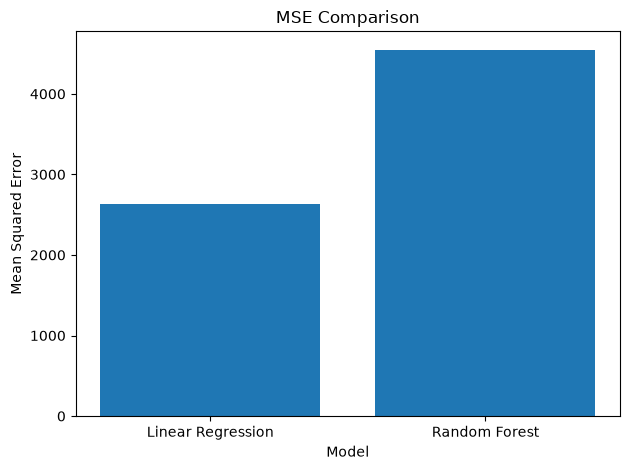

In [15]:
## Step 11: MSE Comparison

# I will create a bar chart to compare the Mean Squared Error of the two models.

# Create the MSE comparison chart
plt.bar(results['Model'], results['MSE'])

plt.title('MSE Comparison')
plt.xlabel('Model')
plt.ylabel('Mean Squared Error')

plt.tight_layout()

# Save the chart
plt.savefig('../reports/assignment3_chart1.png')

plt.show()

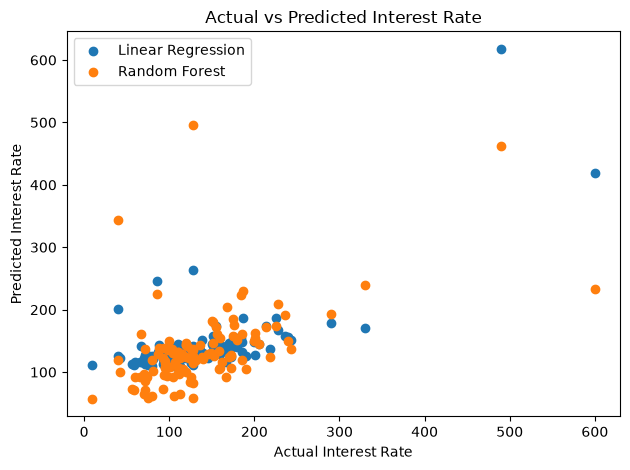

In [17]:
## Step 12: Actual vs Predicted

# This chart compares the actual interest rates with the values predicted by the two models.

# Plot actual vs predicted values
plt.scatter(y_test, y_pred_lr, label='Linear Regression')
plt.scatter(y_test, y_pred_rf, label='Random Forest')

plt.xlabel('Actual Interest Rate')
plt.ylabel('Predicted Interest Rate')
plt.title('Actual vs Predicted Interest Rate')

plt.legend()
plt.tight_layout()

# Save the chart
plt.savefig('../reports/assignment3_chart2.png')

plt.show()

## Step 13: Actual vs Predicted Results

The Actual vs Predicted scatter plot shows that **Linear Regression performed better than Random Forest**.

The Linear Regression predictions are closer to the actual values, which indicates lower prediction error.

The Random Forest predictions are more scattered, which is consistent with its higher MSE.

Therefore, based on the scatter plot and the evaluation results, **Linear Regression performed better for this dataset**.

## Conclusion

In this assignment, I built and compared **Linear Regression** and **Random Forest Regression** models to predict `LoanAmount`.

I evaluated the models using MSE and R² Score.

After comparing Linear Regression and Random Forest, Linear Regression performed better on this dataset.

It achieved a lower MSE and a higher R² Score than Random Forest.

The Actual vs Predicted plot also supports this result because the Linear Regression predictions were closer to the actual values.

Therefore, `Linear Regression` was the better model for predicting LoanAmount in this assignment.